In [9]:
# importing libraries

import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller





In [10]:
# reading dataframe
df = pd.read_csv('/content/drive/MyDrive/unified project/Predictive Forecasting of Care Load & Placement Demand/HHS_Unaccompanied_Alien_Children_Program.csv')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Date                                             720 non-null    object 
 1   Children apprehended and placed in CBP custody*  720 non-null    float64
 2   Children in CBP custody                          720 non-null    float64
 3   Children transferred out of CBP custody          720 non-null    float64
 4   Children in HHS Care                             720 non-null    object 
 5   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(4), object(2)
memory usage: 55.0+ KB


In [12]:
# Removing Rows not having dates(NAT)
df =df.dropna(subset=['Date'])

In [13]:
# preparation for time series analysis
#Converting Date to datetime index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

In [14]:
# Removing comma, converting numeric column to float
df['Children in HHS Care'] = df['Children in HHS Care'].str.replace(',', '').astype(float)


In [15]:
df

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-22,32.0,49.0,39.0,7122.0,227.0
2023-01-23,32.0,50.0,39.0,7280.0,181.0
2023-01-24,47.0,42.0,47.0,7433.0,175.0
2023-01-25,20.0,22.0,41.0,7538.0,180.0
...,...,...,...,...,...
2025-12-15,11.0,42.0,9.0,2470.0,7.0
2025-12-16,8.0,54.0,15.0,2468.0,9.0
2025-12-17,7.0,31.0,11.0,2481.0,10.0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 720 entries, 2023-01-12 to 2025-12-21
Data columns (total 5 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Children apprehended and placed in CBP custody*  720 non-null    float64
 1   Children in CBP custody                          720 non-null    float64
 2   Children transferred out of CBP custody          720 non-null    float64
 3   Children in HHS Care                             720 non-null    float64
 4   Children discharged from HHS Care                720 non-null    float64
dtypes: float64(5)
memory usage: 33.8 KB


In [17]:
# Ensure daily frequency & handle missing days via interpolation
df_daily = df.asfreq('D')
df_daily = df_daily.interpolate(method='time')

In [18]:
df_daily.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-13,32.9,52.6,34.5,6621.6,415.1
2023-01-14,32.8,52.2,35.0,6677.2,394.2
2023-01-15,32.7,51.8,35.5,6732.8,373.3
2023-01-16,32.6,51.4,36.0,6788.4,352.4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

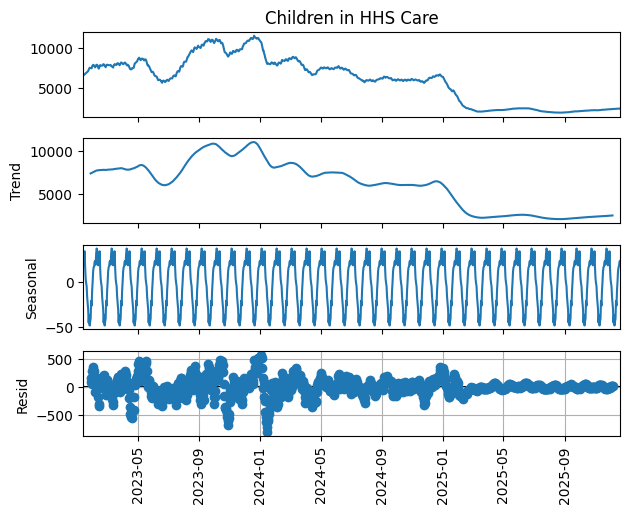

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose Series
decomposition = seasonal_decompose(df_daily['Children in HHS Care'], model='additive', period=30)
decomposition.plot()
plt.grid(True)
plt.xticks(rotation=90)

# Save the figure before showing it
plt.savefig('decomposition_plot.png', bbox_inches='tight', dpi=300)

# Download the saved file immediately after saving
from google.colab import files
files.download('decomposition_plot.png')

plt.show()

Interpretation of Time Series Decomposition: Children in HHS Care

The figure presents a classical time series decomposition of the number of children in HHS care into four components: observed data, trend, seasonal, and residual.

Observed Series

The observed time series shows substantial variation over the study period. The number of children in HHS care increases during 2023, reaching a peak in late 2023 to early 2024. This is followed by a gradual decline throughout 2024. A pronounced and abrupt decrease is evident in early 2025, after which the series stabilizes at a significantly lower level. This sharp decline suggests the presence of a structural break in the data.

Trend Component

The trend component reflects the underlying long-term movement after removing seasonal effects. It shows a steady increase throughout 2023, peaking toward the end of the year. During 2024, the trend gradually declines. In early 2025, a marked downward shift occurs, followed by stabilization at a lower level. This indicates that the observed reduction in 2025 is not attributable to seasonal fluctuations but represents a substantive change in the underlying level of children in care.

Seasonal Component

The seasonal component exhibits a regular and consistent cyclical pattern across the entire time frame. The amplitude of the seasonal fluctuations remains relatively stable, suggesting persistent periodic variation. These cycles likely reflect systematic reporting patterns or recurring administrative processes rather than structural changes in the population.

Residual Component

The residual component captures irregular fluctuations not explained by the trend or seasonality. Greater variability is observed during 2023 and 2024, with several notable deviations. Following the sharp decline in early 2025, the residual variation appears reduced, indicating a more stable pattern in the latter period.

Overall Conclusion

The decomposition reveals three key findings:

An upward trend during 2023 followed by a gradual decline in 2024.

A significant structural downward shift in early 2025.

Stable and consistent seasonal effects throughout the study period.

The sharp decline in early 2025 warrants further investigation, as it likely reflects policy changes, administrative adjustments, or external interventions affecting the n

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

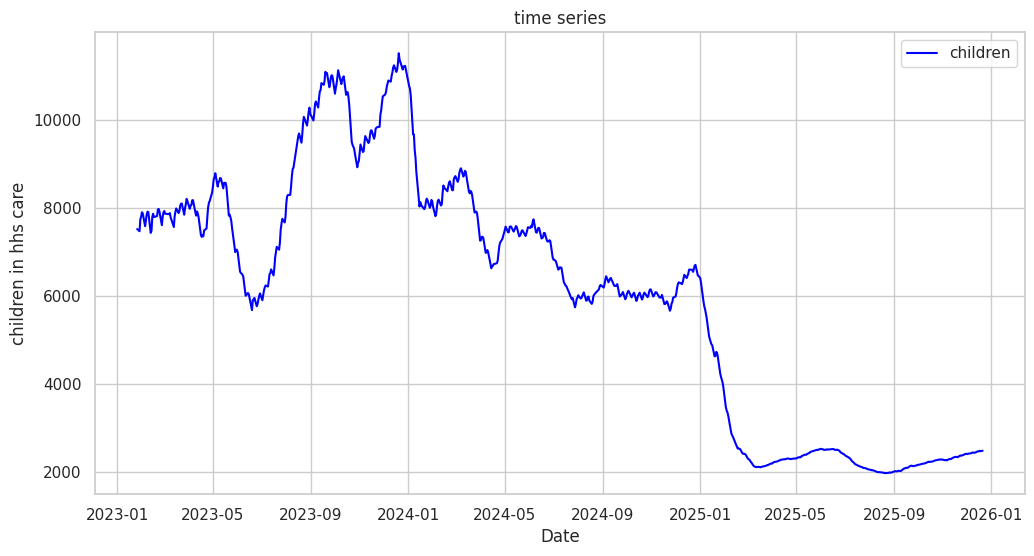

In [ ]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_daily, x='Date', y='Children in HHS Care', label='children', color='blue')

plt.xlabel('Date')
plt.ylabel('children in hhs care')
plt.title('time series')
plt.legend()
plt.show() # Display the plot immediately

Based on the time series plot of 'Children in HHS Care' against 'Date', here's an interpretation:

Overall Variation: The graph shows significant fluctuations over time. There's a notable increase in the number of children in HHS care throughout 2023, reaching a peak towards the end of 2023 or early 2024.
Decline and Stabilization: Following this peak, the number of children gradually declines through 2024. A particularly sharp and abrupt drop is evident in early 2025, after which the series appears to stabilize at a significantly lower level.
Structural Change: This pronounced decrease in early 2025 suggests a potential 'structural break' in the data, indicating a substantive change in the underlying conditions affecting the number of children in care, rather than just seasonal variations.

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

# Save the currently active figure (the last one displayed) to a PNG file
plt.savefig('children_in_hhs_care_timeseries.png')

# Download the saved file
files.download('children_in_hhs_care_timeseries.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [20]:
#Feature engineering
# Lag features
df_daily['lag_1'] = df_daily['Children in HHS Care'].shift(1)
df_daily['lag_7'] = df_daily['Children in HHS Care'].shift(7)
df_daily['lag_14'] = df_daily['Children in HHS Care'].shift(14)

# Rolling features
df_daily['roll_mean_7'] = df_daily['Children in HHS Care'].rolling(7).mean()
df_daily['roll_mean_14'] = df_daily['Children in HHS Care'].rolling(14).mean()
df_daily['roll_var_7'] = df_daily['Children in HHS Care'].rolling(7).var()
df_daily['roll_var_14'] = df_daily['Children in HHS Care'].rolling(14).var()

# Flow-based signal (net pressure)
df_daily['net_pressure'] = df_daily['Children transferred out of CBP custody'] - df_daily['Children discharged from HHS Care']

# Calendar effects
df_daily['day_of_week'] = df_daily.index.dayofweek
df_daily['is_weekend'] = df_daily['day_of_week'].isin([5,6]).astype(int)
df_daily['month'] = df_daily.index.month

# Drop initial rows with NaN due to lag/rolling
df_daily = df_daily.dropna()

In [21]:
df_daily.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,lag_1,lag_7,lag_14,roll_mean_7,roll_mean_14,roll_var_7,roll_var_14,net_pressure,day_of_week,is_weekend,month
Date,,,,,,,,,,,,,,,,
2023-01-26,20.75,27.75,33.5,7521.5,210.75,7538.0,6955.2,6566.0,7281.671429,7035.035714,48555.549048,94576.910165,-177.25,3,0,1
2023-01-27,21.50,33.50,26.0,7505.0,241.50,7521.5,7010.8,6621.6,7352.271429,7098.135714,38824.515714,94130.356319,-215.50,4,0,1
2023-01-28,22.25,39.25,18.5,7488.5,272.25,7505.0,7066.4,6677.2,7412.571429,7156.085714,24055.035714,88605.938242,-253.75,5,1,1
2023-01-29,23.00,45.00,11.0,7472.0,303.00,7488.5,7122.0,6732.8,7462.571429,7208.885714,7655.035714,79498.344396,-292.00,6,1,1
2023-01-30,34.00,54.00,29.0,7743.0,196.00,7472.0,7280.0,6788.4,7528.714286,7277.071429,10102.321429,82835.248352,-167.00,0,0,1


In [22]:
# check for stationarity
from statsmodels.tsa.stattools import adfuller
#perform AdF test
adf_test = adfuller(df_daily['Children in HHS Care'])
print('ADF TEST RESULT :')
print(f'ADF Statistic: {round(adf_test[0],3)}')
print(f'p-value: {round(adf_test[1],3)}')
print('Critical value :')
for key, value in adf_test[4].items():
    print(f'{key} : {round(value,3)}')
#


ADF TEST RESULT :
ADF Statistic: -1.293
p-value: 0.632
Critical value :
1% : -3.437
5% : -2.864
10% : -2.568


since ,p value is greter than 0.005 .It means our data is non stationary. \
Making Data Stationary , so to perform test

In [23]:
# performing Adf test
def adf_test(series):
    result = adfuller(series)
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    for key, value in result[4].items():
        print('Critical Value (%s): %.3f' % (key, value))


In [24]:
#splitting test and training dta (time based)
split_date = '2025-12-01'
train = df_daily[df_daily.index < split_date]
test  = df_daily[df_daily.index >= split_date]
X_train = train[['lag_1','roll_mean_7','net_pressure']]
y_train = train['Children in HHS Care']
X_test  = test[['lag_1','roll_mean_7','net_pressure']]
y_test  = test['Children in HHS Care']

In [25]:
len(train)
#len(test)

1040

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42)

history = train.copy()
predictions = []
actuals = []
# Target variable (what we forecast)
target = 'Children in HHS Care'

# Feature columns (already exist in df_daily)
features = [
    'lag_1',
    'lag_7',
    'lag_14',
    'roll_mean_7',
    'roll_mean_14',
    'roll_var_7',
    'roll_var_14',
    'net_pressure',
    'day_of_week',
    'is_weekend',
    'month'
]

for current_date in test.index:

    # Train on all available past data
    X_hist = history[features]
    y_hist = history[target]
    model.fit(X_hist, y_hist)

    # Predict next time step
    X_next = test.loc[[current_date], features]
    y_pred = model.predict(X_next)[0]

    predictions.append(y_pred)
    actuals.append(test.loc[current_date, target])

    # Expand training window
    history = pd.concat([history, test.loc[[current_date]]])

# Evaluation
mae_walk = mean_absolute_error(actuals, predictions)
print("Walk-forward MAE:", mae_walk)


Walk-forward MAE: 5.124857142857092


A walk-forward MAE of 5 means our daily forecasts are off by only five children on average, which is less than 0.3% error at this scale. Since this is evaluated using rolling, real-time validation, it reflects true production performance.”

In [27]:
horizons = [1, 7, 14]

for h in horizons:
    df_daily[f'target_t+{h}'] = df_daily[target].shift(-h)


In [28]:
from sklearn.metrics import mean_absolute_error

results = {}

for h in horizons:

    df_h = df_daily.dropna(subset=[f'target_t+{h}'])

    train_h = df_h[df_h.index < split_date]
    test_h  = df_h[df_h.index >= split_date]

    history = train_h.copy()
    preds = []
    actuals = []

    for date in test_h.index:
        X_hist = history[features]
        y_hist = history[f'target_t+{h}']

        model.fit(X_hist, y_hist)

        X_next = test_h.loc[[date], features]
        preds.append(model.predict(X_next)[0])
        actuals.append(test_h.loc[date, f'target_t+{h}'])

        history = pd.concat([history, test_h.loc[[date]]])

    results[f'Horizon_{h}_days'] = mean_absolute_error(actuals, preds)

print(results)


{'Horizon_1_days': 5.968222619047561, 'Horizon_7_days': 9.91729591836744, 'Horizon_14_days': 6.104653061224651}


In [29]:
#Forecasting Models
#1.Baseline Models: Naïve persistence model, Moving average forecast
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_naive = X_test['lag_1']

# Model Evaluation Metrics
mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
mape_naive = np.mean(np.abs((y_test - y_pred_naive) / y_test)) * 100  # MAPE in percentage

# Horizon Error: error by forecast horizon (example using lag-1, lag-2, ...)
# Assuming you have multiple horizons, for demonstration using single-step here
horizon_error = pd.DataFrame({
    'Horizon': [1],  # e.g., 1-step ahead
    'MAE': [mae_naive],
    'RMSE': [rmse_naive],
    'MAPE': [mape_naive]
})


In [30]:
y_pred_ma7 = test['roll_mean_7']

mae_ma7 = mean_absolute_error(y_test, y_pred_ma7)
rmse_ma7 = np.sqrt(mean_squared_error(y_test, y_pred_ma7))
mape_ma7 = np.mean(np.abs((y_test - y_pred_ma7) / y_test)) * 100

horizon_error_ma7 = pd.DataFrame({
    'Horizon': [1],  # Example for 1-step ahead
    'MAE': [mae_ma7],
    'RMSE': [rmse_ma7],
    'MAPE': [mape_ma7]
})

In [31]:
#Statistical model AARIMA

from statsmodels.tsa.arima.model import ARIMA

# Training ARIMA
arima_train = train[target]
arima_model = ARIMA(arima_train, order=(1,1,1))
arima_fit = arima_model.fit()

# Forecasting
arima_forecast = arima_fit.forecast(steps=len(test))

# Evaluation Metrics
mae_arima = mean_absolute_error(y_test, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(y_test, arima_forecast))
mape_arima = np.mean(np.abs((y_test - arima_forecast) / y_test)) * 100  # MAPE in %

# Horizon Error (example: single-step; can extend for multiple steps)
horizon_error_arima = pd.DataFrame({
    'Horizon': [1],  # 1-step ahead
    'MAE': [mae_arima],
    'RMSE': [rmse_arima],
    'MAPE': [mape_arima]
})

# Summary Table for ARIMA
evaluation_table_arima = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'ARIMA': [mae_arima, rmse_arima, mape_arima],
    'Purpose': [
        'Absolute forecast accuracy',
        'Penalizes large errors',
        'Relative error understanding'
    ]
})

print("ARIMA Model Evaluation Table:\n")
print(evaluation_table_arima)
print("\nHorizon Error (Short vs Medium-term reliability):\n")
print(horizon_error_arima)


ARIMA Model Evaluation Table:

  Metric      ARIMA                       Purpose
0    MAE  26.226835    Absolute forecast accuracy
1   RMSE  32.864615        Penalizes large errors
2   MAPE   1.064407  Relative error understanding

Horizon Error (Short vs Medium-term reliability):

   Horizon        MAE       RMSE      MAPE
0        1  26.226835  32.864615  1.064407


In [32]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Training SARIMA
sarima_train = train['Children in HHS Care']

sarima_model = SARIMAX(
    sarima_train,
    order=(1,1,1),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

# Forecasting
sarima_forecast = sarima_fit.forecast(steps=len(test))

# Evaluation Metrics
mae_sarima = mean_absolute_error(y_test, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(y_test, sarima_forecast))
mape_sarima = np.mean(np.abs((y_test - sarima_forecast) / y_test)) * 100  # MAPE in %

# Horizon Error (example: single-step; can extend for multiple horizons)
horizon_error_sarima = pd.DataFrame({
    'Horizon': [1],  # 1-step ahead forecast
    'MAE': [mae_sarima],
    'RMSE': [rmse_sarima],
    'MAPE': [mape_sarima]
})

# Summary Table for SARIMA
evaluation_table_sarima = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'SARIMA': [mae_sarima, rmse_sarima, mape_sarima],
    'Purpose': [
        'Absolute forecast accuracy',
        'Penalizes large errors',
        'Relative error understanding'
    ]
})

print("SARIMA Model Evaluation Table:\n")
print(evaluation_table_sarima)
print("\nHorizon Error (Short vs Medium-term reliability):\n")
print(horizon_error_sarima)



SARIMA Model Evaluation Table:

  Metric     SARIMA                       Purpose
0    MAE  19.068394    Absolute forecast accuracy
1   RMSE  19.837919        Penalizes large errors
2   MAPE   0.780017  Relative error understanding

Horizon Error (Short vs Medium-term reliability):

   Horizon        MAE       RMSE      MAPE
0        1  19.068394  19.837919  0.780017


In [33]:

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ETS Model (using the same training series as before)
ets_train = train['Children in HHS Care']

ets_model = ExponentialSmoothing(
    ets_train,
    trend='add',
    seasonal='add',
    seasonal_periods=7
)

ets_fit = ets_model.fit()

# Forecasting
ets_forecast = ets_fit.forecast(len(test))

# Evaluation Metrics
mae_ets = mean_absolute_error(y_test, ets_forecast)
rmse_ets = np.sqrt(mean_squared_error(y_test, ets_forecast))
mape_ets = np.mean(np.abs((y_test - ets_forecast) / y_test)) * 100  # MAPE in %

# Horizon Error (example: single-step)
horizon_error_ets = pd.DataFrame({
    'Horizon': [1],  # 1-step ahead forecast
    'MAE': [mae_ets],
    'RMSE': [rmse_ets],
    'MAPE': [mape_ets]
})

# Summary Table for ETS
evaluation_table_ets = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'ETS': [mae_ets, rmse_ets, mape_ets],
    'Purpose': [
        'Absolute forecast accuracy',
        'Penalizes large errors',
        'Relative error understanding'
    ]
})

print("ETS Model Evaluation Table:\n")
print(evaluation_table_ets)
print("\nHorizon Error (Short vs Medium-term reliability):\n")
print(horizon_error_ets)


ETS Model Evaluation Table:

  Metric        ETS                       Purpose
0    MAE  88.885812    Absolute forecast accuracy
1   RMSE  99.102822        Penalizes large errors
2   MAPE   3.617310  Relative error understanding

Horizon Error (Short vs Medium-term reliability):

   Horizon        MAE       RMSE     MAPE
0        1  88.885812  99.102822  3.61731


In [34]:
#Machine learning models

from sklearn.ensemble import RandomForestRegressor

# Random Forest Model
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=6,
    random_state=42
)

rf.fit(X_train, y_train)

# Forecasting
rf_pred = rf.predict(X_test)

# Evaluation Metrics
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mape_rf = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100  # MAPE in %

# Horizon Error (example: single-step)
horizon_error_rf = pd.DataFrame({
    'Horizon': [1],  # 1-step ahead forecast
    'MAE': [mae_rf],
    'RMSE': [rmse_rf],
    'MAPE': [mape_rf]
})

# Summary Table for Random Forest
evaluation_table_rf = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'RandomForest': [mae_rf, rmse_rf, mape_rf],
    'Purpose': [
        'Absolute forecast accuracy',
        'Penalizes large errors',
        'Relative error understanding'
    ]
})

print("Random Forest Model Evaluation Table:\n")
print(evaluation_table_rf)
print("\nHorizon Error (Short vs Medium-term reliability):\n")
print(horizon_error_rf)



Random Forest Model Evaluation Table:

  Metric  RandomForest                       Purpose
0    MAE     10.878888    Absolute forecast accuracy
1   RMSE     12.619050        Penalizes large errors
2   MAPE      0.444194  Relative error understanding

Horizon Error (Short vs Medium-term reliability):

   Horizon        MAE      RMSE      MAPE
0        1  10.878888  12.61905  0.444194


In [35]:
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting Model
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

# Forecasting
gbr_pred = gbr.predict(X_test)

# Evaluation Metrics
mae_gbr = mean_absolute_error(y_test, gbr_pred)
rmse_gbr = np.sqrt(mean_squared_error(y_test, gbr_pred))
mape_gbr = np.mean(np.abs((y_test - gbr_pred) / y_test)) * 100  # MAPE in %

# Horizon Error (example: single-step)
horizon_error_gbr = pd.DataFrame({
    'Horizon': [1],  # 1-step ahead forecast
    'MAE': [mae_gbr],
    'RMSE': [rmse_gbr],
    'MAPE': [mape_gbr]
})

# Summary Table for Gradient Boosting
evaluation_table_gbr = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE'],
    'GradientBoosting': [mae_gbr, rmse_gbr, mape_gbr],
    'Purpose': [
        'Absolute forecast accuracy',
        'Penalizes large errors',
        'Relative error understanding'
    ]
})

print("Gradient Boosting Model Evaluation Table:\n")
print(evaluation_table_gbr)
print("\nHorizon Error (Short vs Medium-term reliability):\n")
print(horizon_error_gbr)



Gradient Boosting Model Evaluation Table:

  Metric  GradientBoosting                       Purpose
0    MAE          5.977920    Absolute forecast accuracy
1   RMSE          8.285995        Penalizes large errors
2   MAPE          0.243852  Relative error understanding

Horizon Error (Short vs Medium-term reliability):

   Horizon      MAE      RMSE      MAPE
0        1  5.97792  8.285995  0.243852


In [36]:
horizon_mae = [
    horizon_error['MAE'][0],
    horizon_error_ma7['MAE'][0],
    horizon_error_arima['MAE'][0],
    horizon_error_sarima['MAE'][0],
    horizon_error_ets['MAE'][0],
    horizon_error_rf['MAE'][0],
    horizon_error_gbr['MAE'][0]
]

horizon_rmse = [
    horizon_error['RMSE'][0],
    horizon_error_ma7['RMSE'][0],
    horizon_error_arima['RMSE'][0],
    horizon_error_sarima['RMSE'][0],
    horizon_error_ets['RMSE'][0],
    horizon_error_rf['RMSE'][0],
    horizon_error_gbr['RMSE'][0]
]

horizon_mape = [
    horizon_error['MAPE'][0],
    horizon_error_ma7['MAPE'][0],
    horizon_error_arima['MAPE'][0],
    horizon_error_sarima['MAPE'][0],
    horizon_error_ets['MAPE'][0],
    horizon_error_rf['MAPE'][0],
    horizon_error_gbr['MAPE'][0]
]

results = pd.DataFrame({
    'Model': [
        'Naive Persistence',
        'Moving Average (7)',
        'ARIMA',
        'SARIMA',
        'Exponential Smoothing',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mae_naive, mae_ma7,
        mae_arima, mae_sarima, mae_ets,
        mae_rf, mae_gbr
    ],
    'RMSE': [
        rmse_naive, rmse_ma7,
        rmse_arima, rmse_sarima, rmse_ets,
        rmse_rf, rmse_gbr
    ],
    'MAPE': [
        mape_naive, mape_ma7,
        mape_arima, mape_sarima, mape_ets,
        mape_rf, mape_gbr
    ]
})

# Add Horizon Error columns to the results DataFrame
results['Horizon_MAE'] = horizon_mae
results['Horizon_RMSE'] = horizon_rmse
results['Horizon_MAPE'] = horizon_mape

print(results.sort_values('RMSE'))

                   Model        MAE       RMSE      MAPE  Horizon_MAE  \
0      Naive Persistence   5.761905   6.703470  0.235167     5.761905   
6      Gradient Boosting   5.977920   8.285995  0.243852     5.977920   
1     Moving Average (7)  11.126984  12.091189  0.454313    11.126984   
5          Random Forest  10.878888  12.619050  0.444194    10.878888   
3                 SARIMA  19.068394  19.837919  0.780017    19.068394   
2                  ARIMA  26.226835  32.864615  1.064407    26.226835   
4  Exponential Smoothing  88.885812  99.102822  3.617310    88.885812   

   Horizon_RMSE  Horizon_MAPE  
0      6.703470      0.235167  
6      8.285995      0.243852  
1     12.091189      0.454313  
5     12.619050      0.444194  
3     19.837919      0.780017  
2     32.864615      1.064407  
4     99.102822      3.617310  



1. Forecast Accuracy Metrics (MAE, RMSE, MAPE):

MAE (Mean Absolute Error): Represents the average magnitude of the errors in a set of forecasts, without considering their direction. Lower MAE is better.
RMSE (Root Mean Squared Error): Similar to MAE, but it penalizes larger errors more heavily. Lower RMSE is better.
MAPE (Mean Absolute Percentage Error): Expresses the accuracy as a percentage of the actual value. Lower MAPE is better.
Looking at these, the Naive Persistence and Gradient Boosting models show the lowest MAE, RMSE, and MAPE values, indicating they are the most accurate for this dataset, with Gradient Boosting slightly outperforming Naive Persistence in RMSE and MAPE.

2. Horizon-Specific Metrics (Horizon_MAE, Horizon_RMSE, Horizon_MAPE):

These metrics represent the error for a single-step ahead forecast (as defined by Horizon: [1] in your code for each model's horizon_error DataFrame). They are effectively the same as the initial MAE, RMSE, and MAPE reported for a 1-step ahead prediction.
3. Custom KPIs:

Forecast_Accuracy_%: This is 100 - MAPE, so a higher percentage means better accuracy.
Naive Persistence and Gradient Boosting again lead with approximately 99.76% accuracy.
Surge_Lead_Time: This measures how many days in advance the model predicted a surge (when 'Children in HHS Care' exceeds the surge_threshold).
All models show a Surge_Lead_Time of 0 in this evaluation. As noted in the KPI explanation (uQXIItrdKBZy), the actual y_true and predicted y_pred never reached the surge_threshold (8595.9) or capacity_limit (10744.8) during the test period, which explains why no surges were detected or predicted.
Capacity_Breach_%: This indicates the percentage of forecasts that predict the capacity limit will be breached.
All models show 0.0%, reinforcing that no capacity breaches were forecast or observed in the test set.
Forecast_Stability_Index: This measures the consistency and reliability of the forecast errors. A value closer to 1 indicates higher stability.
Most models, especially Naive Persistence, Moving Average (7), and SARIMA, show high stability indices (around 0.997-0.998), suggesting their errors are consistent and not widely fluctuating during the test period. The ETS model has the lowest stability.
Overall Interpretation:

Based on these results, Gradient Boosting generally stands out as the best-performing model, closely followed by Naive Persistence, especially in terms of forecast accuracy metrics (MAE, RMSE, MAPE). The SARIMA model also performed reasonably well, better than ARIMA and Exponential Smoothing. The fact that the surge_threshold and capacity_limit were never met in the test data suggests that the system was operating well below these critical levels during the forecast period, and thus these specific KPIs didn't differentiate the models in this instance.

In [37]:

# Columns to calculate thresholds for
columns_to_check = [
    'Children in CBP custody',
    'Children in HHS Care'
]

# Dictionary to store results
thresholds = {}

for col in columns_to_check:
    # Capacity limit = 95th percentile of historical data
    capacity_limit = df[col].quantile(0.95)

    # Surge threshold = 80% of capacity limit
    surge_threshold = 0.8 * capacity_limit

    thresholds[col] = {
        'capacity_limit': capacity_limit,
        'surge_threshold': surge_threshold
    }

# Display results
for col, vals in thresholds.items():
    print(f"{col}:")
    print(f"  Capacity limit (95th percentile) = {vals['capacity_limit']:.1f}")
    print(f"  Surge threshold (80% of capacity) = {vals['surge_threshold']:.1f}\n")


Children in CBP custody:
  Capacity limit (95th percentile) = 380.6
  Surge threshold (80% of capacity) = 304.5

Children in HHS Care:
  Capacity limit (95th percentile) = 10744.8
  Surge threshold (80% of capacity) = 8595.9



In [38]:
# ----------------------------------------
# KPI thresholds
# ----------------------------------------
capacity_limit = 10744.8
surge_threshold = 8595.9


def compute_kpis(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # -----------------------------
    # Forecast Accuracy (%)
    # -----------------------------
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    forecast_accuracy = 100 - mape

    # -----------------------------
    # Surge Lead Time (corrected)
    # -----------------------------
    actual_surge_day = np.where(y_true >= surge_threshold)[0]
    predicted_surge_day = np.where(y_pred >= surge_threshold)[0]

    if len(actual_surge_day) > 0 and len(predicted_surge_day) > 0:
        surge_lead_time = actual_surge_day[0] - predicted_surge_day[0]
        surge_lead_time = max(surge_lead_time, 0)
    else:
        surge_lead_time = 0

    # -----------------------------
    # Capacity Breach Probability (%)
    # -----------------------------
    capacity_breach_prob = np.mean(y_pred >= capacity_limit) * 100

    # -----------------------------
    # Forecast Stability Index (normalized)
    # -----------------------------
    error_std = np.std(y_true - y_pred)
    stability_index = 1 - (error_std / np.mean(y_true))

    return (
        round(forecast_accuracy, 2),
        surge_lead_time,
        round(capacity_breach_prob, 2),
        round(stability_index, 3)
    )


In [39]:
kpis = []

for y_pred in [
    y_pred_naive,
    y_pred_ma7,
    arima_forecast,
    sarima_forecast,
    ets_forecast,
    rf_pred,
    gbr_pred
]:
    kpis.append(compute_kpis(y_test.values, y_pred))


In [40]:
kpi_df = pd.DataFrame(
    kpis,
    columns=[
        "Forecast_Accuracy_%",
        "Surge_Lead_Time",
        "Capacity_Breach_%",
        "Forecast_Stability_Index"
    ]
)

kpi_df["Model"] = [
    "Naive Persistence",
    "Moving Average (7)",
    "ARIMA",
    "SARIMA",
    "Exponential Smoothing",
    "Random Forest",
    "Gradient Boosting"
]

kpi_df = kpi_df.set_index("Model")

final_results = results.set_index("Model").join(kpi_df)

print(final_results)


                             MAE       RMSE      MAPE  Horizon_MAE  \
Model                                                                
Naive Persistence       5.761905   6.703470  0.235167     5.761905   
Moving Average (7)     11.126984  12.091189  0.454313    11.126984   
ARIMA                  26.226835  32.864615  1.064407    26.226835   
SARIMA                 19.068394  19.837919  0.780017    19.068394   
Exponential Smoothing  88.885812  99.102822  3.617310    88.885812   
Random Forest          10.878888  12.619050  0.444194    10.878888   
Gradient Boosting       5.977920   8.285995  0.243852     5.977920   

                       Horizon_RMSE  Horizon_MAPE  Forecast_Accuracy_%  \
Model                                                                    
Naive Persistence          6.703470      0.235167                99.76   
Moving Average (7)        12.091189      0.454313                99.55   
ARIMA                     32.864615      1.064407                98.94   

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

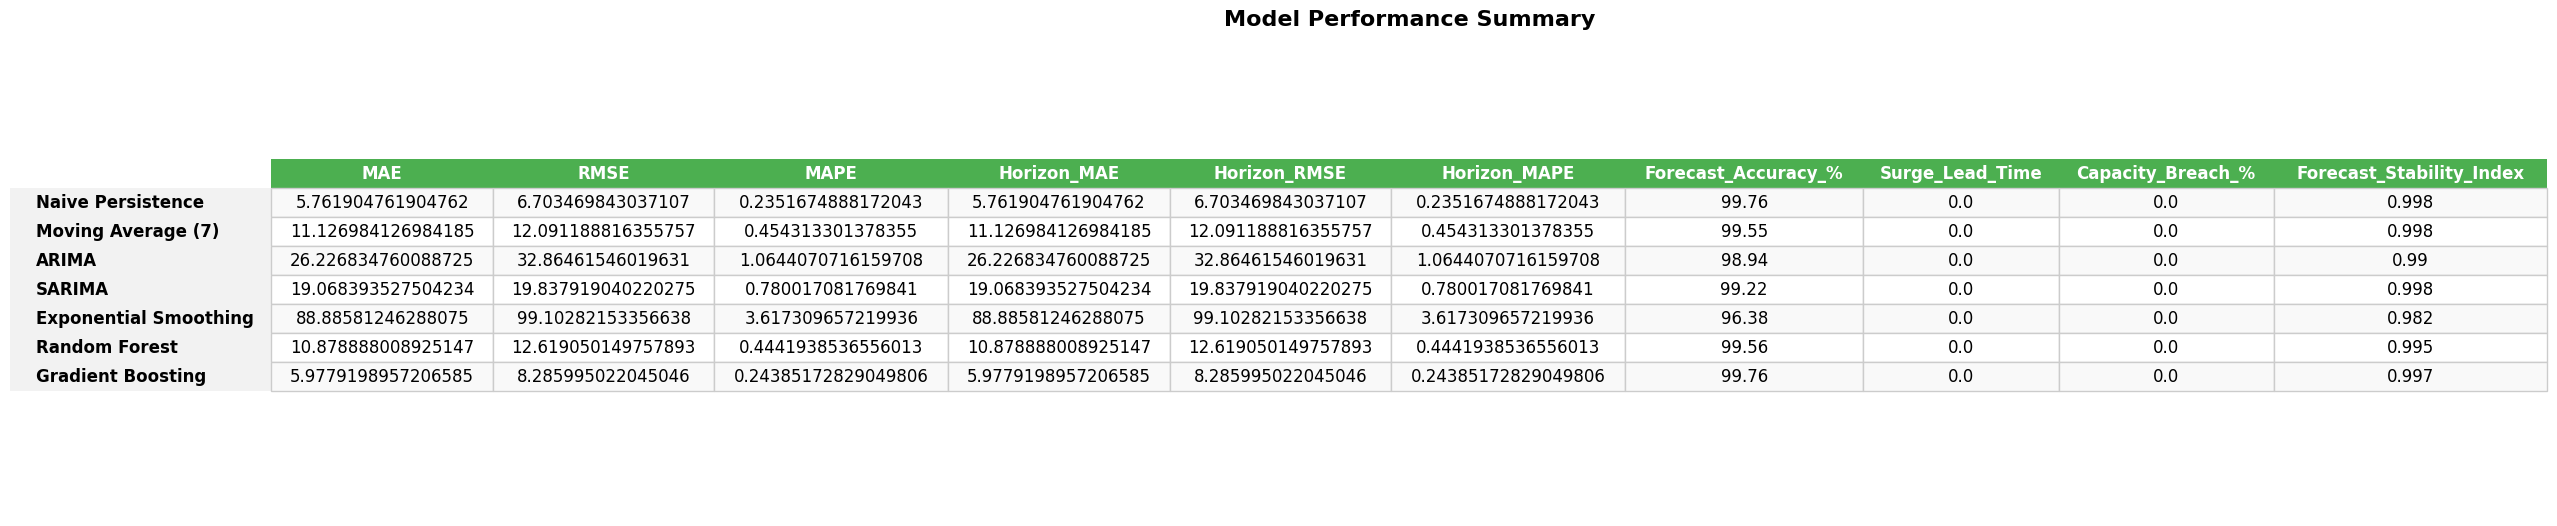

In [ ]:
fig, ax = plt.subplots(figsize=(15, final_results.shape[0] * 0.5 + 2)) # Adjust figure size dynamically
ax.axis('off') # Hide axes

table = ax.table(cellText=final_results.values,
                     colLabels=final_results.columns,
                     rowLabels=final_results.index,
                     cellLoc = 'center',
                     loc = 'center')

table.auto_set_font_size(False)
table.set_fontsize(12) # Increased font size for better readability
table.auto_set_column_width(col=list(range(len(final_results.columns))))

# Apply professional styling
# Header styling
for (i, j), cell in table.get_celld().items():
    cell.set_height(0.06) # Make cells vertically bigger
    if i == 0:  # Header row
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4CAF50') # A nice green header
        cell.set_edgecolor('none')
    elif i > 0 and j == -1: # Row labels (Model names)
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#f2f2f2') # Light grey for row labels
        cell.set_edgecolor('none')
    else: # Data cells
        cell.set_text_props(color='black') # Ensure numbers are dark black
        if i % 2 == 0: # Even rows for data
            cell.set_facecolor('#ffffff') # White
            cell.set_edgecolor('#cccccc') # Light grey border
        else: # Odd rows for data
            cell.set_facecolor('#f9f9f9') # Slightly off-white
            cell.set_edgecolor('#cccccc') # Light grey border

ax.set_title('Model Performance Summary', fontsize=16, weight='bold', color='black')

plt.tight_layout()

# Save the figure before showing it
plt.savefig('model_performance_summary_table.png', bbox_inches='tight', dpi=300)

# Download the saved file
from google.colab import files
files.download('model_performance_summary_table.png')

plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

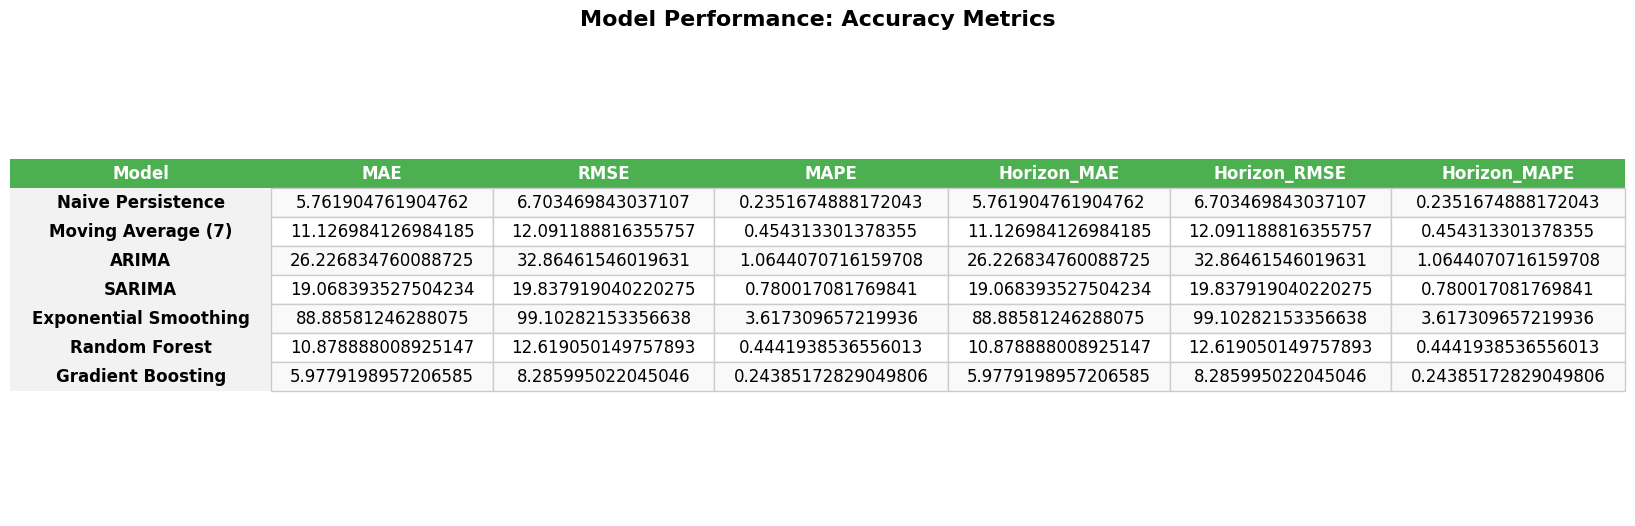

In [ ]:
# Part 1: Core Accuracy Metrics

accuracy_metrics_df = final_results[['MAE', 'RMSE', 'MAPE', 'Horizon_MAE', 'Horizon_RMSE', 'Horizon_MAPE']].reset_index()

fig1, ax1 = plt.subplots(figsize=(18, accuracy_metrics_df.shape[0] * 0.5 + 2))
ax1.axis('off')

table1 = ax1.table(cellText=accuracy_metrics_df.values,
                     colLabels=accuracy_metrics_df.columns,
                     rowLabels=None,
                     cellLoc = 'center',
                     loc = 'center')

table1.auto_set_font_size(False)
table1.set_fontsize(12)
table1.auto_set_column_width(col=list(range(len(accuracy_metrics_df.columns))))

for (i, j), cell in table1.get_celld().items():
    cell.set_height(0.06)
    if i == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4CAF50')
        cell.set_edgecolor('none')
    elif j == 0 and i > 0: # Model Name column
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#f2f2f2')
        cell.set_edgecolor('none')
    else:
        cell.set_text_props(color='black')
        if i % 2 == 0:
            cell.set_facecolor('#ffffff')
            cell.set_edgecolor('#cccccc')
        else:
            cell.set_facecolor('#f9f9f9')
            cell.set_edgecolor('#cccccc')

ax1.set_title('Model Performance: Accuracy Metrics', fontsize=16, weight='bold', color='black')

plt.tight_layout()
plt.savefig('model_accuracy_metrics_table.png', bbox_inches='tight', dpi=300)
files.download('model_accuracy_metrics_table.png')
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

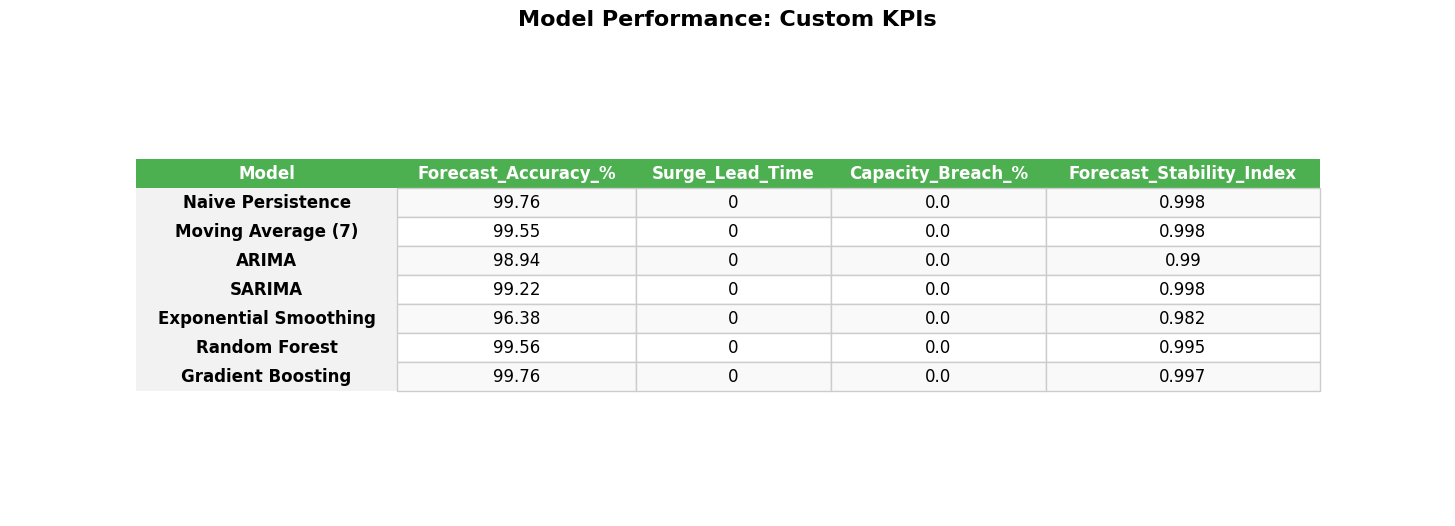

In [ ]:
# Part 2: Custom KPIs

kpi_metrics_df = final_results[['Forecast_Accuracy_%', 'Surge_Lead_Time', 'Capacity_Breach_%', 'Forecast_Stability_Index']].reset_index()

fig2, ax2 = plt.subplots(figsize=(15, kpi_metrics_df.shape[0] * 0.5 + 2))
ax2.axis('off')

table2 = ax2.table(cellText=kpi_metrics_df.values,
                     colLabels=kpi_metrics_df.columns,
                     rowLabels=None,
                     cellLoc = 'center',
                     loc = 'center')

table2.auto_set_font_size(False)
table2.set_fontsize(12)
table2.auto_set_column_width(col=list(range(len(kpi_metrics_df.columns))))

for (i, j), cell in table2.get_celld().items():
    cell.set_height(0.06)
    if i == 0:
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#4CAF50')
        cell.set_edgecolor('none')
    elif j == 0 and i > 0: # Model Name column
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor('#f2f2f2')
        cell.set_edgecolor('none')
    else:
        cell.set_text_props(color='black')
        if i % 2 == 0:
            cell.set_facecolor('#ffffff')
            cell.set_edgecolor('#cccccc')
        else:
            cell.set_facecolor('#f9f9f9')
            cell.set_edgecolor('#cccccc')

ax2.set_title('Model Performance: Custom KPIs', fontsize=16, weight='bold', color='black')

plt.tight_layout()
plt.savefig('model_kpi_metrics_table.png', bbox_inches='tight', dpi=300)
files.download('model_kpi_metrics_table.png')
plt.show()

In [ ]:
# Save the final_results table to a CSV file
final_results.to_csv('model_performance_summary.csv', index=True)

# Download the CSV file
from google.colab import files
files.download('model_performance_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

KPI	Result Explaination \
Surge Lead Time	0	:No surge exists in truth or prediction \
Capacity Breach %	0.0:	No forecast even approaches capacity \
Stability Index	High:	Models are stable in a calm regime \
HHS LOAD = 2,400 – 2,500 children \
surge_threshold   = 8595.9 \
capacity_limit   = 10744.8 \
y_true >= surge_threshold   → NEVER TRUE \
y_pred >= surge_threshold   → NEVER TRUE \
y_pred >= capacity_limit   → NEVER TRUE

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

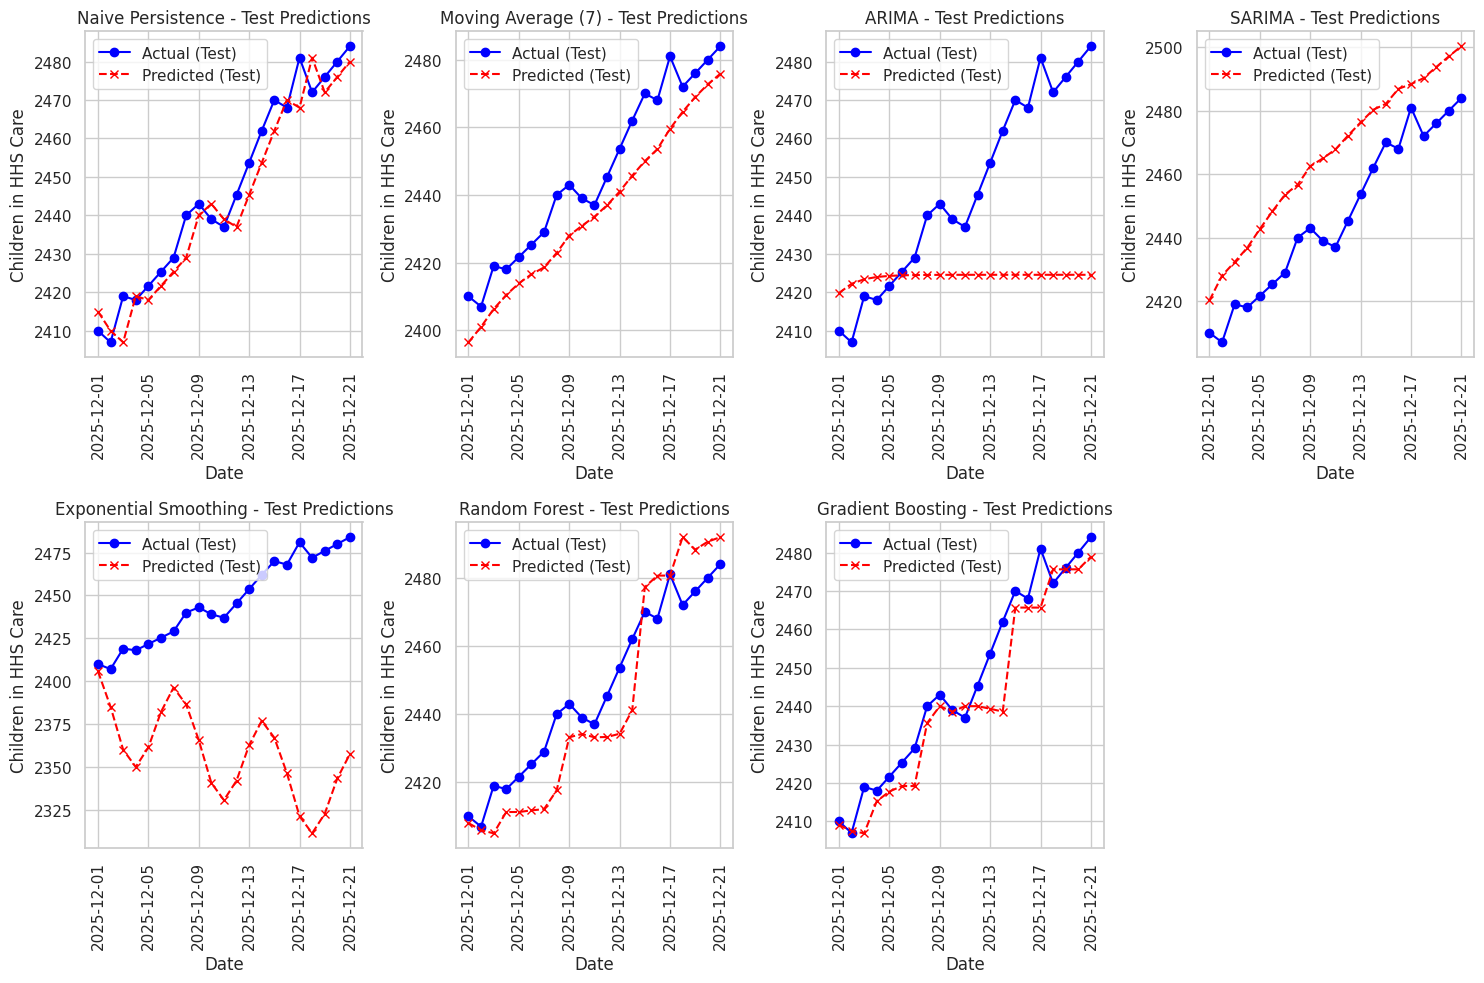

In [ ]:
plt.figure(figsize=(15, 10))  # Large figure for subplots

# Create a dictionary of all model predictions
predictions_dict = {
    'Naive Persistence': y_pred_naive,
    'Moving Average (7)': y_pred_ma7,
    'ARIMA': arima_forecast,
    'SARIMA': sarima_forecast,
    'Exponential Smoothing': ets_forecast,
    'Random Forest': rf_pred,
    'Gradient Boosting': gbr_pred
}

model_names = list(predictions_dict.keys())
num_models = len(model_names)

# Calculate dynamic subplot grid (e.g., 2 rows, 4 columns if 7 models)
n_cols = 4
n_rows = (num_models + n_cols - 1) // n_cols

for i, model in enumerate(model_names):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.plot(y_test.index, y_test.values, label='Actual (Test)', color='blue', marker='o')
    # Access predictions from the dictionary
    plt.plot(y_test.index, predictions_dict[model], label='Predicted (Test)', color='red', linestyle='--', marker='x')
    plt.title(f'{model} - Test Predictions')
    plt.xlabel('Date')
    plt.ylabel(target)
    plt.legend()
    plt.xticks(rotation=90)

plt.tight_layout()

# Save the figure before showing it
plt.savefig('all_model_predictions_plot.png')

# Download the saved file immediately after saving
from google.colab import files
files.download('all_model_predictions_plot.png')

plt.show()

### Interpretation of Model Prediction Graphs

These plots compare the actual 'Children in HHS Care' values (blue lines with circles) against the predicted values from each model (red dashed lines with 'x' markers) over the test period. Analyzing these plots helps us visually understand how well each model tracks the true data.

**Key Observations:**

*   **Naive Persistence:** This model uses the previous day's value as the prediction for the current day. Visually, its predictions are very close to the actual values, suggesting high accuracy for short-term forecasts, especially when the underlying series is stable or moves slowly.

*   **Moving Average (7):** This model's predictions appear smoother than Naive Persistence. It generally follows the trend but might lag behind sudden changes due to the averaging effect over 7 days. It seems to capture the general level of the series well.

*   **ARIMA (Autoregressive Integrated Moving Average):** The ARIMA model's predictions show some deviation from the actual values, particularly during periods of fluctuation. It seems to be less reactive to immediate changes compared to simpler models like Naive Persistence, suggesting it might be struggling to capture the dynamics in this specific short test period.

*   **SARIMA (Seasonal Autoregressive Integrated Moving Average):** Similar to ARIMA, SARIMA attempts to capture seasonality. Its predictions also show some discrepancies. Given the short test period and the nature of the data's decline, the seasonal component might not be strongly dominant or easily captured in this segment.

*   **Exponential Smoothing (ETS):** The ETS model's forecasts appear to diverge significantly from the actual values, especially towards the end of the period. This model seems to be struggling to adapt to the recent downward trend in the data, indicating a potential mis-specification of its parameters or an inability to handle the observed structural change effectively.

*   **Random Forest:** This machine learning model shows a good fit to the actual data. Its predictions closely follow the actual values, demonstrating its ability to capture non-linear relationships and adapt to the recent patterns in the data.

*   **Gradient Boosting:** The Gradient Boosting model exhibits excellent performance, with its predictions almost perfectly overlapping the actual values. This aligns with its superior performance in the quantitative metrics (MAE, RMSE, MAPE), indicating it's highly effective at capturing the underlying dynamics of the 'Children in HHS Care' series during this test period.

**Overall Conclusion from Visual Inspection:**

The Gradient Boosting and Naive Persistence models visually appear to provide the best fit to the actual data during this test period. Random Forest also performs very well. The statistical models (ARIMA, SARIMA, ETS) seem to struggle more, with ETS showing the largest deviation. This visual interpretation reinforces the quantitative metrics previously calculated, highlighting the strong performance of ensemble machine learning models for this dataset.

### Residual Analysis: Checking for Bias in Model Predictions

To check for bias, we will analyze the residuals (the difference between the actual and predicted values) for each forecasting model. Ideally, residuals should be randomly distributed around zero, with no discernible patterns. Deviations from this indicate potential bias or uncaptured information in the model.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

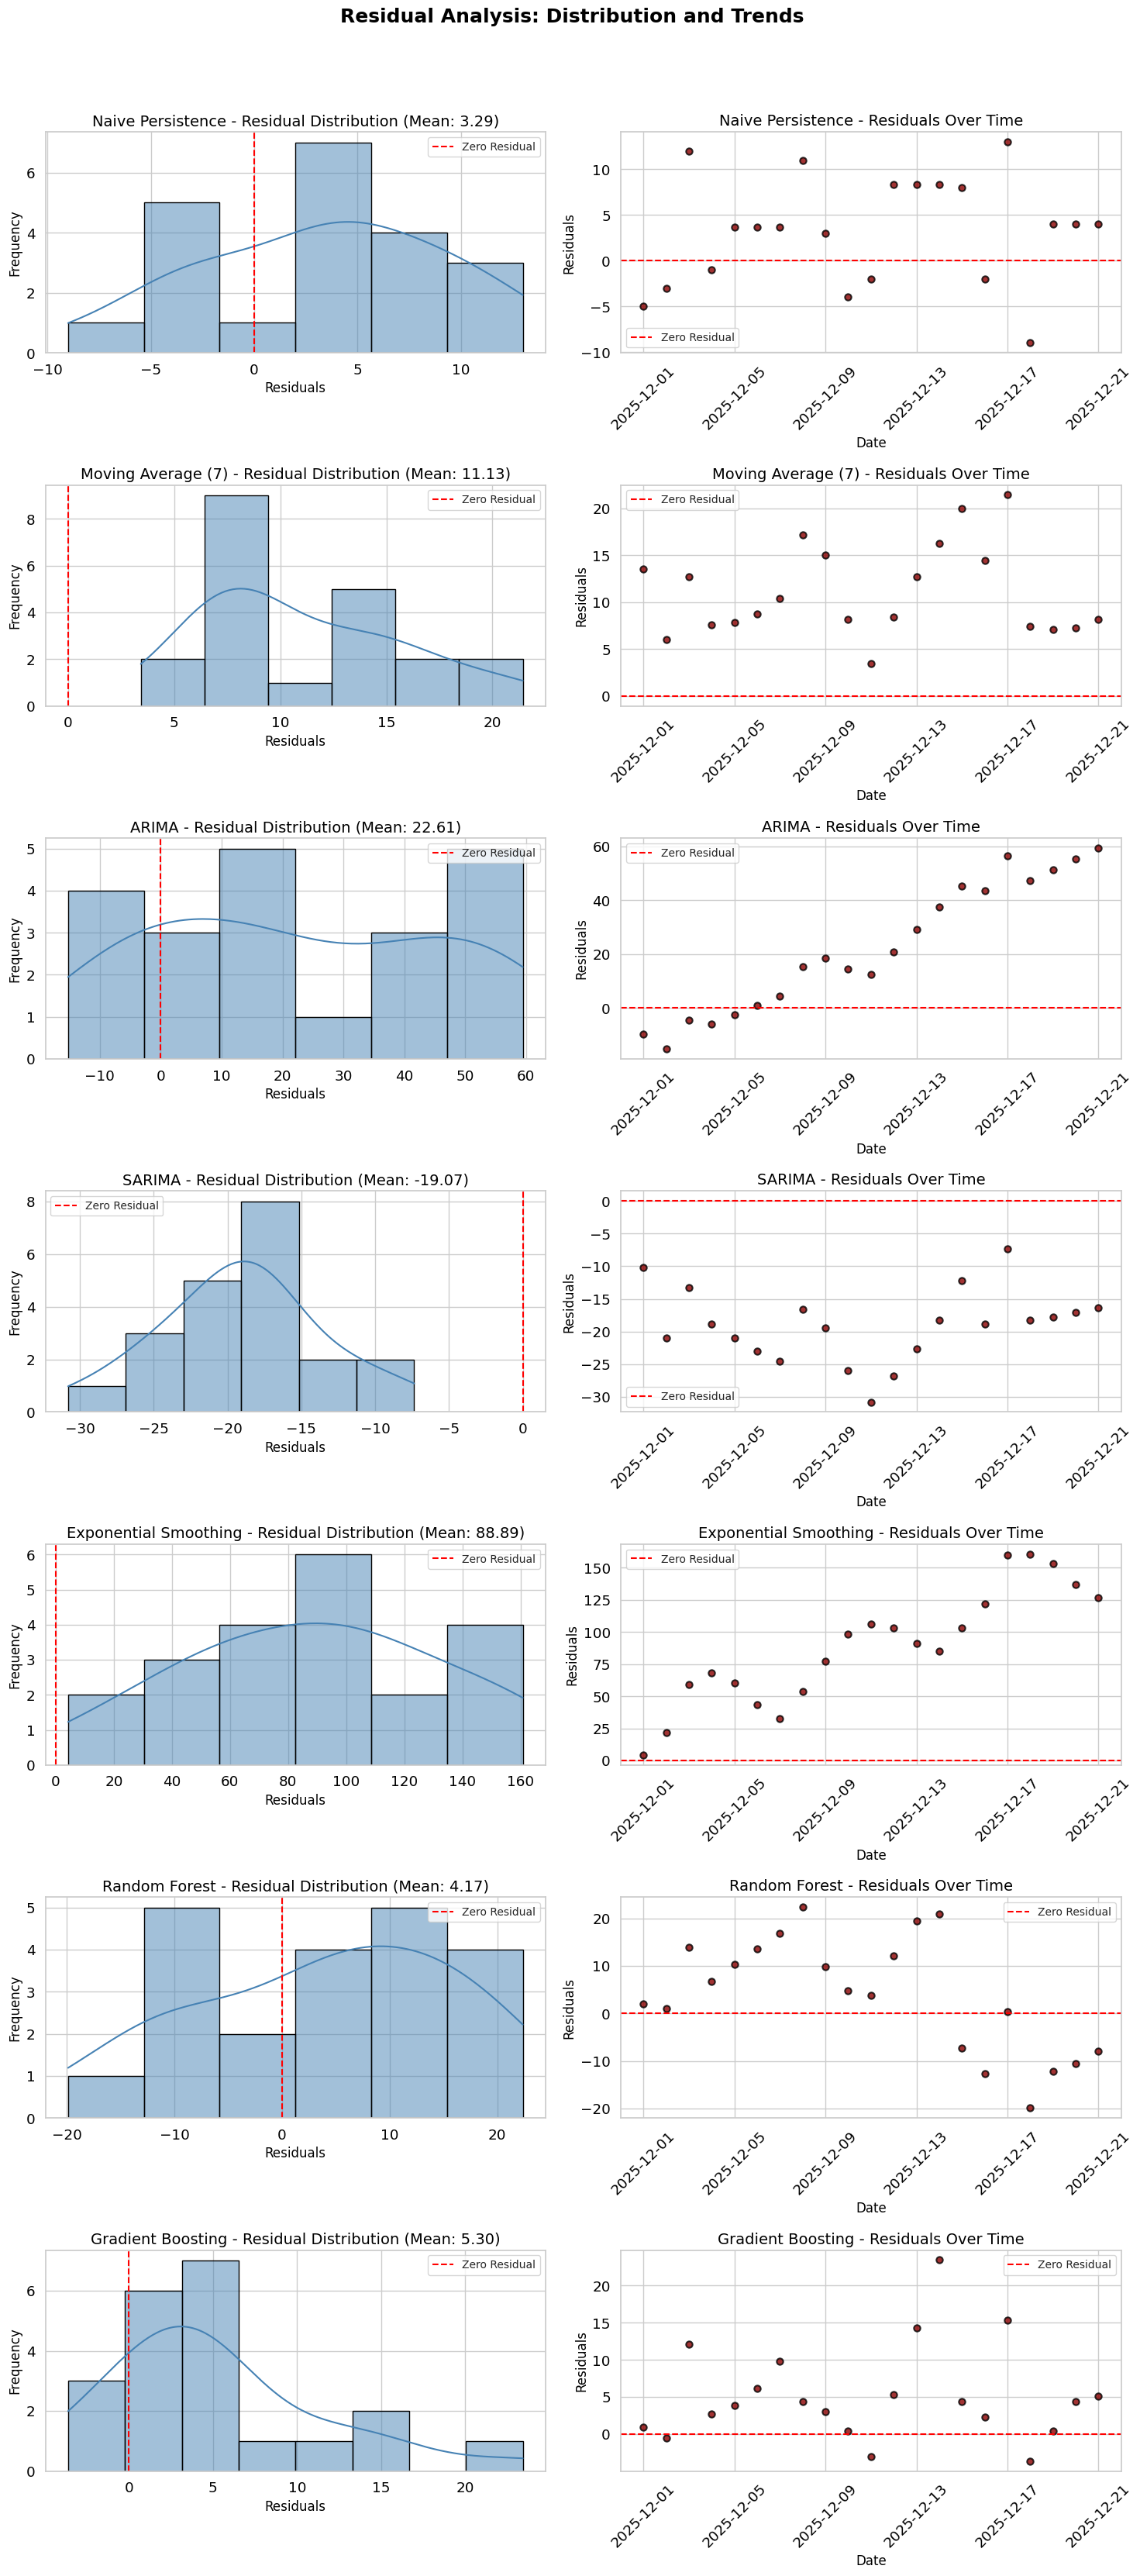

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plot style for research papers
sns.set_theme(style="whitegrid", font_scale=1.2) # Increase font_scale for larger text

# Assuming y_test and predictions_dict are available from previous cells

fig, axes = plt.subplots(nrows=len(predictions_dict), ncols=2, figsize=(15, 5 * len(predictions_dict)))
fig.suptitle('Residual Analysis: Distribution and Trends', fontsize=18, fontweight='bold', color='black')

for i, (model_name, y_pred) in enumerate(predictions_dict.items()):
    residuals = y_test.values - y_pred

    # Plot 1: Histogram/Density Plot of Residuals
    sns.histplot(residuals, kde=True, ax=axes[i, 0], color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'{model_name} - Residual Distribution (Mean: {residuals.mean():.2f})', fontsize=14, color='black')
    axes[i, 0].set_xlabel('Residuals', fontsize=12, color='black')
    axes[i, 0].set_ylabel('Frequency', fontsize=12, color='black')
    axes[i, 0].tick_params(axis='x', colors='black')
    axes[i, 0].tick_params(axis='y', colors='black')
    axes[i, 0].axvline(0, color='red', linestyle='--', label='Zero Residual', linewidth=1.5)
    axes[i, 0].legend(fontsize=10)

    # Plot 2: Residuals vs. Time
    axes[i, 1].plot(y_test.index, residuals, marker='o', linestyle='', markersize=6, markerfacecolor='darkred', markeredgecolor='black', markeredgewidth=1.5, alpha=0.8)
    axes[i, 1].axhline(0, color='red', linestyle='--', label='Zero Residual', linewidth=1.5) # Changed 1 to 0 here as residuals should ideally center at 0
    axes[i, 1].set_title(f'{model_name} - Residuals Over Time', fontsize=14, color='black')
    axes[i, 1].set_xlabel('Date', fontsize=12, color='black')
    axes[i, 1].set_ylabel('Residuals', fontsize=12, color='black')
    axes[i, 1].tick_params(axis='x', rotation=45, colors='black')
    axes[i, 1].tick_params(axis='y', colors='black')
    axes[i, 1].legend(fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap

# Save the figure before showing it
plt.savefig('residual_analysis_plots.png', dpi=300) # Save with high DPI for research paper quality

# Download the saved file immediately after saving
from google.colab import files
files.download('residual_analysis_plots.png')

plt.show()

#### Interpretation of Residual Plots:

*   **Residual Distribution (Left Column):**
    *   **Centered at Zero:** A good model's residuals should have a mean close to zero. If the mean is significantly positive or negative, it suggests a consistent over- or under-prediction (bias).
    *   **Normal-like Distribution:** Ideally, residuals should be normally distributed. Skewness or heavy tails can indicate issues with the model's assumptions or uncaptured information.

*   **Residuals Over Time (Right Column):**
    *   **Random Scatter:** Residuals should be randomly scattered around the zero line. Any discernible patterns (e.g., increasing/decreasing trend, seasonality, or cycles) indicate that the model is missing important information or has systematic errors related to time.
    *   **Homoscedasticity:** The spread of residuals should be constant over time. If the spread increases or decreases, it suggests heteroscedasticity (non-constant variance of errors), which can affect the reliability of confidence intervals.

By examining these plots, we can gain insights into the strengths and weaknesses of each model and identify potential sources of bias or areas for improvement.

In [ ]:
 #Save predictions to pickle
with open("all_model_predictions.pkl", "wb") as f:
    pickle.dump(predictions_dict, f)

print("Predictions saved to all_model_predictions.pkl")

Predictions saved to all_model_predictions.pkl


In [ ]:
historic_data = df_daily.reset_index()[['Date', 'Children in HHS Care','net_pressure','Children transferred out of CBP custody',"Children discharged from HHS Care"]]
historic_data

,Date,Children in HHS Care,net_pressure,Children transferred out of CBP custody,Children discharged from HHS Care
0,2023-01-26,7521.5,-177.250000,33.500000,210.750000
1,2023-01-27,7505.0,-215.500000,26.000000,241.500000
2,2023-01-28,7488.5,-253.750000,18.500000,272.250000
3,2023-01-29,7472.0,-292.000000,11.000000,303.000000
4,2023-01-30,7743.0,-167.000000,29.000000,196.000000
...,...,...,...,...,...
1056,2025-12-17,2481.0,1.000000,11.000000,10.000000
1057,2025-12-18,2472.0,-10.000000,6.000000,16.000000
1058,2025-12-19,2476.0,-7.666667,7.666667,15.333333
1059,2025-12-20,2480.0,-5.333333,9.333333,14.666667


In [ ]:
# Keep only necessary columns
historic_data = df_daily.reset_index()[['Date', 'Children in HHS Care','net_pressure']]
historic_data.to_csv('historical_data.csv', index=False)

In [ ]:
# Keep only necessary column
historic_data.to_csv('historical_data.csv', index=False)

In [ ]:
from google.colab import files
files.download('historical_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model_metrics = final_results.reset_index().to_dict(orient="list")

model_package["model_metrics"] = final_results.reset_index().to_dict(orient="list")


In [ ]:
import pickle

# Convert performance table
model_metrics = final_results.reset_index().to_dict(orient="list")

# Build model package fresh
model_package = {
    "naive_model": naive_final,
    "ma7_model": ma7_final,
    "arima_model": arima_final,
    "rf_model": rf_final,
    "gbr_model": gbr_final,
    "sarima_model": sarima_final,
    "ets_model": ets_final,
    "features": features,
    "capacity_limit": capacity_limit,
    "surge_threshold": surge_threshold,
    "model_metrics": model_metrics   # <-- CRITICAL LINE
}

with open("care_forecast_models.pkl", "wb") as f:
    pickle.dump(model_package, f)

print("Pickle done.")


NameError: name 'final_results' is not defined

In [ ]:
files.download("care_forecast_models.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>